In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from pathlib import Path

In [2]:
MODELS = {
    'qwen3:4b-instruct': 'qwen3:4b-instruct'.replace(':', '_'),
    'gemma3:4b': 'gemma3:4b'.replace(':', '_'),
    'llama3.1:8b-instruct-q3_K_M': 'llama3.1:8b-instruct-q3_K_M'.replace(':', '_'),
    'mistral:7b-instruct': 'mistral:7b-instruct'.replace(':', '_'),
    'deepseek-r1:7b': 'deepseek-r1:7b'.replace(':', '_'),
    'granite3.1-moe:3b': 'granite3.1-moe:3b'.replace(':', '_')
}

# Mapping per nomi semplificati da usare nei grafici
MODEL_DISPLAY_NAMES = {
    'qwen3_4b-instruct': 'Qwen3 4B',
    'gemma3_4b': 'Gemma3 4B',
    'llama3.1_8b-instruct-q3_K_M': 'Llama 3.1 8B',
    'mistral_7b-instruct': 'Mistral 7B',
    'deepseek-r1_7b': 'DeepSeek R1 7B',
    'granite3.1-moe_3b': 'Granite 3.1 MoE 3B'
}

# Verifica mapping
print("Mapping modelli:")
for orig, clean in MODELS.items():
    display_name = MODEL_DISPLAY_NAMES[clean]
    print(f"  {orig} -> {clean} -> {display_name}")

BASE_DIR = "../Output Performance Degradation Analysis"

# Colori per i modelli
MODEL_COLORS = {
    'qwen3_4b-instruct': '#1f77b4',      # Blu
    'gemma3_4b': '#ff7f0e',              # Arancione
    'llama3.1_8b-instruct-q3_K_M': '#2ca02c',  # Verde
    'mistral_7b-instruct': '#d62728',    # Rosso
    'deepseek-r1_7b': '#9467bd',         # Viola
    'granite3.1-moe_3b': '#8c564b'       # Marrone
}

# Colori per le metriche
METRIC_COLORS = {
    'json_em': '#1f77b4',
    'bleu_translate': '#ff7f0e',
    'em_sentiment': '#2ca02c',
    'em_emotion': '#d62728',
    'em_topic': '#9467bd',
    'f1_ner': '#8c564b'
}

print(f"Configurazione completata per {len(MODELS)} modelli")

Mapping modelli:
  qwen3:4b-instruct -> qwen3_4b-instruct -> Qwen3 4B
  gemma3:4b -> gemma3_4b -> Gemma3 4B
  llama3.1:8b-instruct-q3_K_M -> llama3.1_8b-instruct-q3_K_M -> Llama 3.1 8B
  mistral:7b-instruct -> mistral_7b-instruct -> Mistral 7B
  deepseek-r1:7b -> deepseek-r1_7b -> DeepSeek R1 7B
  granite3.1-moe:3b -> granite3.1-moe_3b -> Granite 3.1 MoE 3B
Configurazione completata per 6 modelli


In [3]:
def load_all_model_data():
    """Carica i dati di tutti i modelli dai CSV summary."""
    all_data = {}
    
    for model_name, model_clean in MODELS.items():
        csv_path = f"{BASE_DIR}/evaluation_summary_with_review_{model_clean}_6tasks.csv"
        
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                all_data[model_clean] = df
                print(f"✓ Caricato: {model_name} ({len(df)} righe)")
            except Exception as e:
                print(f"❌ Errore caricando {model_name}: {e}")
        else:
            print(f"❌ File non trovato: {csv_path}")
    
    return all_data

In [4]:
print("=" * 60)
print("CARICAMENTO DATI MODELLI")
print("=" * 60)

all_data = load_all_model_data()

if not all_data:
    print("❌ Nessun dato trovato. Verifica i percorsi dei file.")
else:
    print(f"\n✅ Caricati dati per {len(all_data)} modelli")

CARICAMENTO DATI MODELLI
✓ Caricato: qwen3:4b-instruct (21 righe)
✓ Caricato: gemma3:4b (21 righe)
✓ Caricato: llama3.1:8b-instruct-q3_K_M (21 righe)
✓ Caricato: mistral:7b-instruct (21 righe)
✓ Caricato: deepseek-r1:7b (21 righe)
✓ Caricato: granite3.1-moe:3b (21 righe)

✅ Caricati dati per 6 modelli


In [5]:
def get_final_performance_data(all_data):
    """Estrae i dati delle performance finali per ogni modello."""
    final_data = {}
    
    task_metrics = {
        1: ['json_em'],
        2: ['json_em', 'bleu_translate'],
        3: ['json_em', 'bleu_translate', 'em_sentiment'],
        4: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion'],
        5: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic'],
        6: ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner']
    }
    
    for model_name, df in all_data.items():
        model_data = {}
        
        for task in range(1, 7):
            task_df = df[df['task_number'] == task]
            if not task_df.empty:
                last_row = task_df.iloc[-1]
                
                task_data = {}
                for metric in task_metrics[task]:
                    value = last_row[metric]
                    if pd.notna(value):
                        task_data[metric] = value
                    else:
                        task_data[metric] = 0
                
                model_data[task] = task_data
        
        final_data[model_name] = model_data
    
    return final_data

def get_degradation_data(all_data):
    """Estrae i dati di degradazione per ogni metrica e modello."""
    degradation_data = {}
    
    metrics = ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner']
    
    for metric in metrics:
        degradation_data[metric] = {}
        
        for model_name, df in all_data.items():
            tasks = []
            values = []
            
            for task in range(1, 7):
                task_df = df[df['task_number'] == task]
                if not task_df.empty:
                    last_row = task_df.iloc[-1]
                    
                    if metric in last_row and pd.notna(last_row[metric]):
                        tasks.append(task)
                        values.append(last_row[metric])
            
            if tasks and values:
                degradation_data[metric][model_name] = (tasks, values)
    
    return degradation_data

In [6]:
print("📈 Elaborazione dati per grafici...")
final_data = get_final_performance_data(all_data)
degradation_data = get_degradation_data(all_data)
print("✅ Dati elaborati")

📈 Elaborazione dati per grafici...
✅ Dati elaborati


In [7]:
output_dir = f"{BASE_DIR}"
os.makedirs(output_dir, exist_ok=True)
print(f"📁 Directory output creata: {output_dir}")

📁 Directory output creata: ../Output Performance Degradation Analysis


In [8]:
# [8] Grafico 1: Performance finale comparativa - NOMI SEMPLIFICATI
def create_final_performance_comparison(final_data, output_dir):
    """Crea 6 grafici separati, uno per ogni modello con nomi semplificati."""
    
    task_metrics = {
        1: [('json_em', 'JSON EM')],
        2: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans')],
        3: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM')],
        4: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM')],
        5: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM')],
        6: [('json_em', 'JSON EM'), ('bleu_translate', 'BLEU Trans'), ('em_sentiment', 'Sentiment EM'), ('em_emotion', 'Emotion EM'), ('em_topic', 'Topic EM'), ('f1_ner', 'NER F1')]
    }
    
    model_names = list(final_data.keys())
    
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    fig.suptitle('Final Performance Comparison Across Tasks - All Models', fontsize=18, fontweight='bold')
    
    axes_flat = axes.flatten()
    
    for idx, model_name in enumerate(model_names):
        ax = axes_flat[idx]
        # USA NOME SEMPLIFICATO
        model_display = MODEL_DISPLAY_NAMES[model_name]
        
        model_data = final_data[model_name]
        
        current_position = 0
        bar_width = 0.6
        group_spacing = 1.5
        all_positions = []
        all_labels = []
        
        for task in range(1, 7):
            task_start_pos = current_position
            
            for i, (metric_key, metric_label) in enumerate(task_metrics[task]):
                pos = current_position
                
                value = 0
                if task in model_data and metric_key in model_data[task]:
                    value = model_data[task][metric_key]
                
                color = METRIC_COLORS[metric_key]
                
                bar = ax.bar(pos, value, width=bar_width, color=color, alpha=0.8)
                
                if value > 0:
                    ax.text(pos, value + 1, f'{value:.1f}', ha='center', va='bottom', 
                           fontsize=9, fontweight='bold')
                
                current_position += bar_width + 0.2
            
            task_center = task_start_pos + (len(task_metrics[task]) * (bar_width + 0.2) - 0.2) / 2
            all_positions.append(task_center)
            all_labels.append(f'Task {task}')
            
            current_position += group_spacing
        
        ax.set_xticks(all_positions)
        ax.set_xticklabels(all_labels, rotation=0, ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'{model_display}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Performance (%)', fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, 110)
        
        for label in ax.get_xticklabels():
            label.set_color('black')
        
        separator_positions = []
        current_pos = 0
        for task in range(1, 7):
            if task > 1:
                task_start = current_pos - group_spacing/2
                separator_positions.append(task_start)
            current_pos += len(task_metrics[task]) * (bar_width + 0.2) + group_spacing
        
        for sep_pos in separator_positions:
            ax.axvline(x=sep_pos, color='gray', linestyle='--', alpha=0.5)
    
    for idx in range(len(model_names), 6):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/multi_model_final_performance_comparison_corrected.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"✅ Grafico comparativo salvato")

In [9]:
def create_degradation_overview(degradation_data, output_dir):
    """Crea il grafico overview della degradazione con nomi semplificati."""
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Multi-Model Performance Degradation Analysis', fontsize=20, fontweight='bold', y=0.96)
    
    subplot_config = [
        ('json_em', 'JSON Exact Match (%)', axes[0, 0], range(1, 7)),
        ('bleu_translate', 'BLEU Translation Score (%)', axes[0, 1], range(2, 7)),
        ('em_sentiment', 'Sentiment Classification (%)', axes[0, 2], range(3, 7)),
        ('em_emotion', 'Emotion Classification (%)', axes[1, 0], range(4, 7)),
        ('em_topic', 'Topic Classification (%)', axes[1, 1], range(5, 7)),
        ('f1_ner', 'Named Entity Recognition F1 (%)', axes[1, 2], range(6, 7))
    ]
    
    markers = ['o', 's', '^', 'D', 'v', 'p']
    marker_sizes = [10, 9, 10, 8, 10, 9]
    
    legend_handles = []
    legend_labels = []
    
    for metric, title, ax, task_range in subplot_config:
        if metric in degradation_data and degradation_data[metric]:
            all_values = []
            all_tasks = []
            
            for idx, (model_name, (tasks, values)) in enumerate(degradation_data[metric].items()):
                if tasks and values:
                    filtered_data = [(t, v) for t, v in zip(tasks, values) if t in task_range]
                    if filtered_data:
                        filtered_tasks, filtered_values = zip(*filtered_data)
                        all_values.extend(filtered_values)
                        all_tasks.extend(filtered_tasks)
                        
                        color = MODEL_COLORS[model_name]
                        # USA NOME SEMPLIFICATO
                        label = MODEL_DISPLAY_NAMES[model_name]
                        marker = markers[idx % len(markers)]
                        marker_size = marker_sizes[idx % len(marker_sizes)]
                        
                        line = ax.plot(filtered_tasks, filtered_values, 
                                     marker=marker, color=color, linestyle='-',
                                     linewidth=3.5, markersize=marker_size, label=label, 
                                     alpha=0.85, markeredgewidth=2, markeredgecolor='white',
                                     markerfacecolor=color, zorder=5)
                        
                        if metric == 'json_em':
                            legend_handles.append(line[0])
                            legend_labels.append(label)
                        
                        for i, (task, value) in enumerate(zip(filtered_tasks, filtered_values)):
                            if i == 0 or i == len(filtered_tasks)-1 or len(filtered_tasks) <= 3:
                                ax.annotate(f'{value:.0f}', (task, value), 
                                          textcoords="offset points", xytext=(0, 15), 
                                          ha='center', fontsize=9, fontweight='bold',
                                          bbox=dict(boxstyle='round,pad=0.25', 
                                                   facecolor='white', edgecolor=color, 
                                                   alpha=0.9, linewidth=1.5),
                                          zorder=10)
            
            task_list = sorted(set(task_range))
            ax.set_xticks(task_list)
            ax.set_xticklabels([f'Task {t}' for t in task_list], fontsize=11, fontweight='bold')
            
            if task_list:
                x_padding = 0.1
                ax.set_xlim(min(task_list) - x_padding, max(task_list) + x_padding)
            
            if all_values:
                min_val, max_val = min(all_values), max(all_values)
                y_range = max_val - min_val
                y_padding = max(5, y_range * 0.1)
                ax.set_ylim(max(0, min_val - y_padding), min(105, max_val + y_padding))
            
        else:
            ax.text(0.5, 0.5, f'No Data Available', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=14, fontweight='bold', color='gray', alpha=0.7)
            task_list = list(task_range)
            ax.set_xticks(task_list)
            ax.set_xticklabels([f'Task {t}' for t in task_list], fontsize=11)
            if task_list:
                ax.set_xlim(min(task_list) - 0.1, max(task_list) + 0.1)
        
        ax.set_title(title, fontsize=15, fontweight='bold', pad=20, color='#2c3e50')
        ax.set_xlabel('Task Number', fontsize=12, fontweight='bold', color='#34495e')
        ax.set_ylabel('Performance (%)', fontsize=12, fontweight='bold', color='#34495e')
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, color='gray')
        ax.set_axisbelow(True)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('#34495e')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['bottom'].set_color('#34495e')
        
        ax.tick_params(axis='both', which='major', labelsize=10, 
                      colors='#2c3e50', width=1.2, length=6)
    
    if legend_handles:
        fig.legend(legend_handles, legend_labels, 
                  loc='lower center', bbox_to_anchor=(0.5, -0.02), 
                  ncol=3, fontsize=11, frameon=True, 
                  fancybox=True, shadow=True, framealpha=0.95,
                  edgecolor='#34495e', facecolor='white')
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.94])
    plt.savefig(f'{output_dir}/multi_model_performance_degradation_overview_final.png', 
                dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    
    print(f"✅ Grafico overview salvato")

In [10]:
def create_overall_degradation_chart(final_data, output_dir):
    """Crea un grafico a barre con formula corretta e legenda semplificata."""
    
    degradation_results = {}
    
    metrics_for_degradation = {
        'json_em': (1, 6),
        'bleu_translate': (2, 6),
        'em_sentiment': (3, 6),
        'em_emotion': (4, 6),
        'em_topic': (5, 6),
        'f1_ner': (6, 6)
    }
    
    for model_name, model_data in final_data.items():
        # USA NOME SEMPLIFICATO
        model_display = MODEL_DISPLAY_NAMES[model_name]
        degradations = []
        
        for metric, (start_task, end_task) in metrics_for_degradation.items():
            if metric == 'f1_ner':
                continue
                
            if start_task in model_data and end_task in model_data:
                start_value = model_data[start_task].get(metric, 0)
                end_value = model_data[end_task].get(metric, 0)
                
                if start_value > 0:
                    # FORMULA CORRETTA: ((finale - iniziale) / iniziale) * 100
                    change_pct = ((end_value - start_value) / start_value) * 100
                    degradations.append(change_pct)
                    status = "miglioramento" if change_pct > 0 else "degradazione"
                    print(f"{model_display} - {metric}: {start_value:.1f}% → {end_value:.1f}% ({status}: {change_pct:+.1f}%)")
        
        if degradations:
            avg_change = sum(degradations) / len(degradations)
            degradation_results[model_display] = {
                'avg_change': avg_change,
                'individual_changes': degradations,
                'n_metrics': len(degradations)
            }
            status = "miglioramento" if avg_change > 0 else "degradazione"
            print(f"{model_display} - {status.title()} medio: {avg_change:+.1f}%\n")
    
    # Ordina i modelli per performance change (dal peggiore al migliore)
    sorted_models = sorted(degradation_results.items(), 
                          key=lambda x: x[1]['avg_change'])
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    models = [item[0] for item in sorted_models]
    values = [item[1]['avg_change'] for item in sorted_models]
    
    # Colori basati su degradazione vs miglioramento
    colors = []
    for val in values:
        if val < -20:
            colors.append('#c0392b')      # Rosso scuro - degradazione molto alta
        elif val < -10:
            colors.append('#e74c3c')      # Rosso - degradazione alta  
        elif val < -5:
            colors.append('#f39c12')      # Arancione - degradazione media
        elif val < 0:
            colors.append('#f1c40f')      # Giallo - degradazione bassa
        else:
            colors.append('#27ae60')      # Verde - miglioramento (unico verde)
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=2.5, width=0.7)
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        if val >= 0:
            y_pos = bar.get_height() + max(abs(max(values)), abs(min(values))) * 0.02
            va = 'bottom'
        else:
            y_pos = bar.get_height() - max(abs(max(values)), abs(min(values))) * 0.02
            va = 'top'
            
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f'{val:+.1f}%', ha='center', va=va, 
                fontsize=12, fontweight='bold', color='#2c3e50')
    
    ax.axhline(y=0, color='#34495e', linestyle='-', linewidth=1.5, alpha=0.8)
    
    ax.set_title('Performance Change by Model: Multi-Task Impact Analysis\n(From Initial to Final Task)', 
                fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
    ax.set_xlabel('Model', fontsize=14, fontweight='bold', color='#34495e')
    ax.set_ylabel('Average Performance Change (%)', fontsize=14, fontweight='bold', color='#34495e')
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    
    y_max = max(abs(max(values)), abs(min(values))) * 1.2
    ax.set_ylim(-y_max, y_max)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['left'].set_color('#34495e')
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['bottom'].set_color('#34495e')
    
    # LEGENDA SEMPLIFICATA (un solo verde)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#c0392b', label='Severe Degradation (< -20%)'),
        Patch(facecolor='#e74c3c', label='High Degradation (-10% to -20%)'),
        Patch(facecolor='#f39c12', label='Medium Degradation (-5% to -10%)'),
        Patch(facecolor='#f1c40f', label='Low Degradation (0% to -5%)'),
        Patch(facecolor='#27ae60', label='Improvement (> 0%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
             fontsize=10, framealpha=0.95, fancybox=True, shadow=True)
    
    # Zone colorate di sfondo
    ax.axhspan(-y_max, 0, alpha=0.05, color='red', label='Degradation Zone')
    ax.axhspan(0, y_max, alpha=0.05, color='green', label='Improvement Zone')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/overall_model_performance_change_analysis_final.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"✅ Grafico analisi performance salvato")
    
    print("\n" + "="*70)
    print("RIEPILOGO IMPATTO MULTI-TASK SUI MODELLI")
    print("="*70)
    for model, data in sorted_models:
        change = data['avg_change']
        if change < 0:
            status = f"DEGRADA del {abs(change):.1f}%"
        else:
            status = f"MIGLIORA del {change:.1f}%"
        print(f"{model:20s}: {status:20s} (su {data['n_metrics']} metriche)")
    
    print(f"\n🏆 MIGLIORE (meno degradazione): {sorted_models[-1][0]}")
    print(f"❌ PEGGIORE (più degradazione):   {sorted_models[0][0]}")

In [11]:
def create_absolute_performance_chart(final_data, output_dir):
    """Crea un grafico che mostra le performance assolute finali con nomi semplificati."""
    
    absolute_results = {}
    
    task6_metrics = ['json_em', 'bleu_translate', 'em_sentiment', 'em_emotion', 'em_topic', 'f1_ner']
    
    for model_name, model_data in final_data.items():
        # USA NOME SEMPLIFICATO
        model_display = MODEL_DISPLAY_NAMES[model_name]
        
        if 6 in model_data:
            task6_data = model_data[6]
            values = []
            
            for metric in task6_metrics:
                if metric in task6_data and task6_data[metric] > 0:
                    values.append(task6_data[metric])
            
            if values:
                avg_performance = sum(values) / len(values)
                absolute_results[model_display] = {
                    'avg_performance': avg_performance,
                    'individual_values': values,
                    'n_metrics': len(values),
                    'task6_data': task6_data
                }
                print(f"{model_display} - Performance media Task 6: {avg_performance:.1f}% (su {len(values)} metriche)")
    
    sorted_models = sorted(absolute_results.items(), 
                          key=lambda x: x[1]['avg_performance'], reverse=True)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    
    models = [item[0] for item in sorted_models]
    performances = [item[1]['avg_performance'] for item in sorted_models]
    
    colors = []
    for perf in performances:
        if perf >= 80:
            colors.append('#27ae60')      # Verde scuro - performance eccellente
        elif perf >= 70:
            colors.append('#2ecc71')      # Verde - performance buona
        elif perf >= 60:
            colors.append('#f1c40f')      # Giallo - performance media
        elif perf >= 50:
            colors.append('#f39c12')      # Arancione - performance bassa
        else:
            colors.append('#e74c3c')      # Rosso - performance scarsa
    
    bars = ax.bar(range(len(models)), performances, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=2.5, width=0.7)
    
    for i, (bar, perf) in enumerate(zip(bars, performances)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{perf:.1f}%', ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='#2c3e50')
    
    ax.set_title('Final Absolute Performance by Model\n(Average across all metrics at Task 6)', 
                fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
    ax.set_xlabel('Model', fontsize=14, fontweight='bold', color='#34495e')
    ax.set_ylabel('Average Performance (%)', fontsize=14, fontweight='bold', color='#34495e')
    
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=12, fontweight='bold')
    
    ax.set_ylim(0, 105)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, axis='y')
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['left'].set_color('#34495e')
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['bottom'].set_color('#34495e')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#27ae60', label='Excellent (≥80%)'),
        Patch(facecolor='#2ecc71', label='Good (70-80%)'),
        Patch(facecolor='#f1c40f', label='Average (60-70%)'),
        Patch(facecolor='#f39c12', label='Below Average (50-60%)'),
        Patch(facecolor='#e74c3c', label='Poor (<50%)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
             fontsize=11, framealpha=0.95, fancybox=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/absolute_final_performance_comparison_final.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"✅ Grafico performance assolute salvato")
    
    print("\n" + "="*70)
    print("RANKING PERFORMANCE ASSOLUTE FINALI (TASK 6)")
    print("="*70)
    for i, (model, data) in enumerate(sorted_models, 1):
        perf = data['avg_performance']
        print(f"{i:2d}. {model:20s}: {perf:5.1f}% (su {data['n_metrics']} metriche)")
    
    print(f"\n🥇 MIGLIORE PERFORMANCE ASSOLUTA: {sorted_models[0][0]} ({sorted_models[0][1]['avg_performance']:.1f}%)")
    print(f"🥉 PERFORMANCE PIU' BASSA:        {sorted_models[-1][0]} ({sorted_models[-1][1]['avg_performance']:.1f}%)")
    
    return sorted_models

🎨 Generazione grafico comparativo delle performance finali...


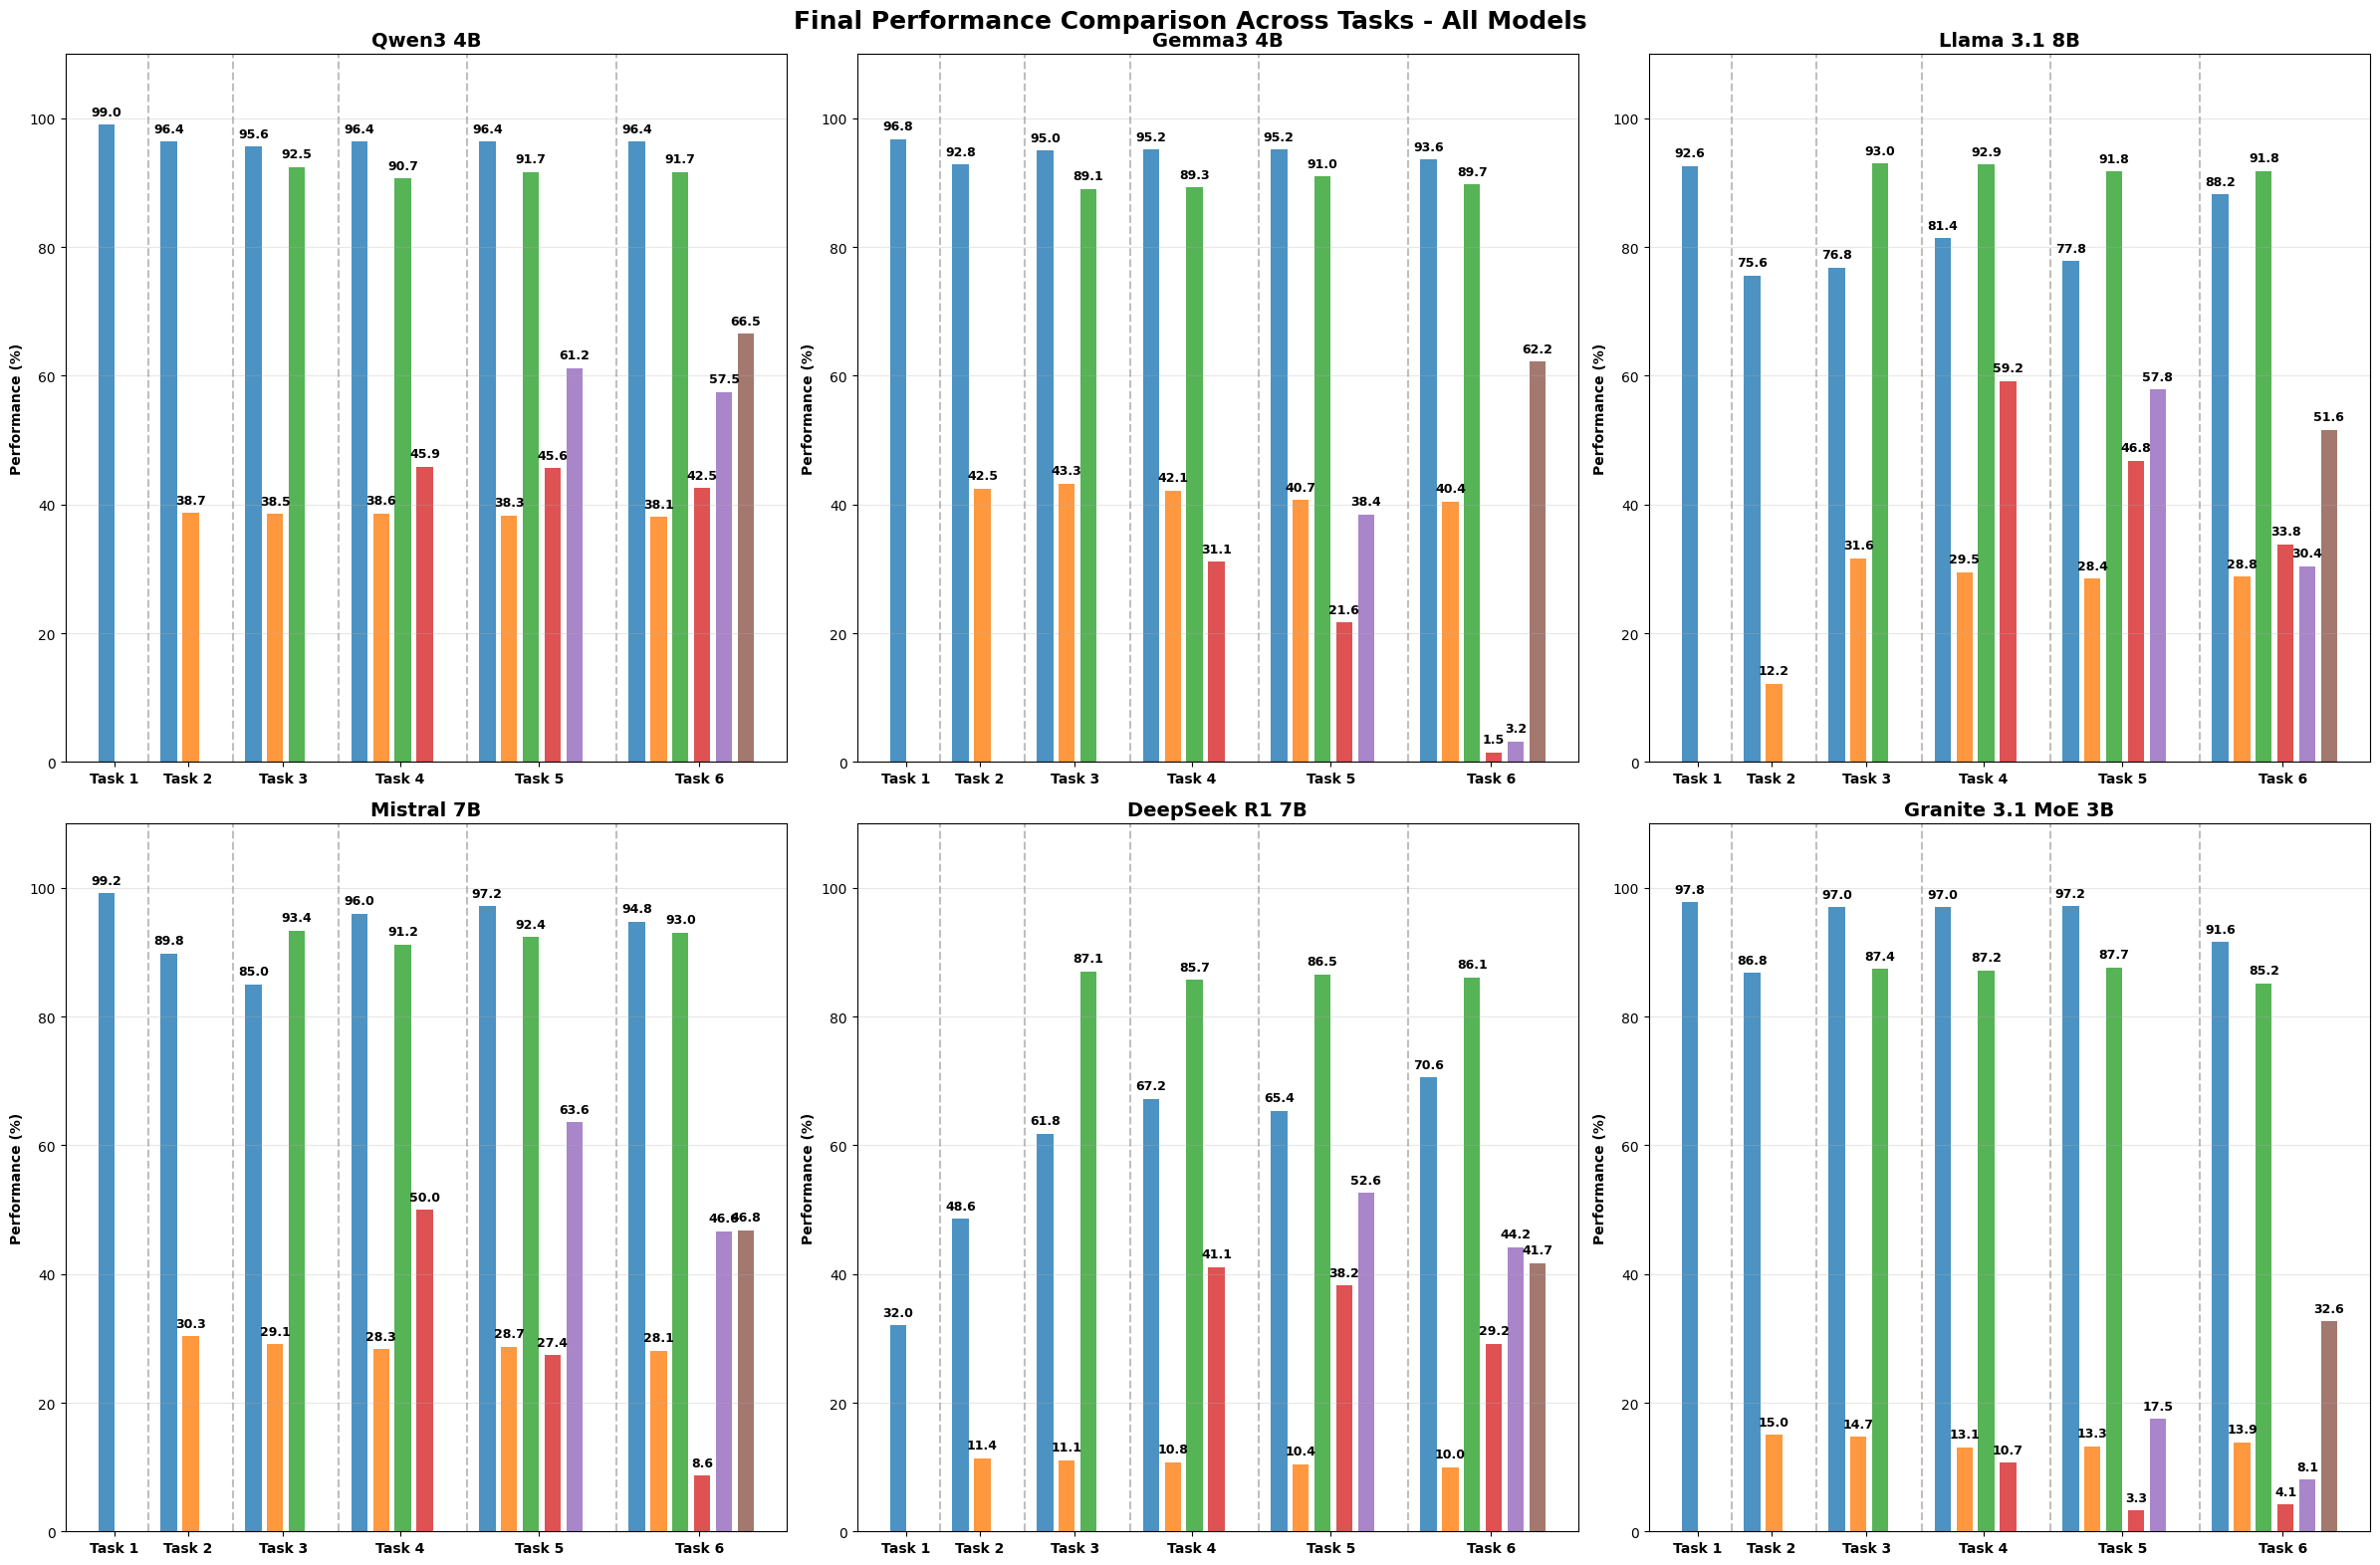

✅ Grafico comparativo salvato
🎨 Generazione grafico overview degradazione...


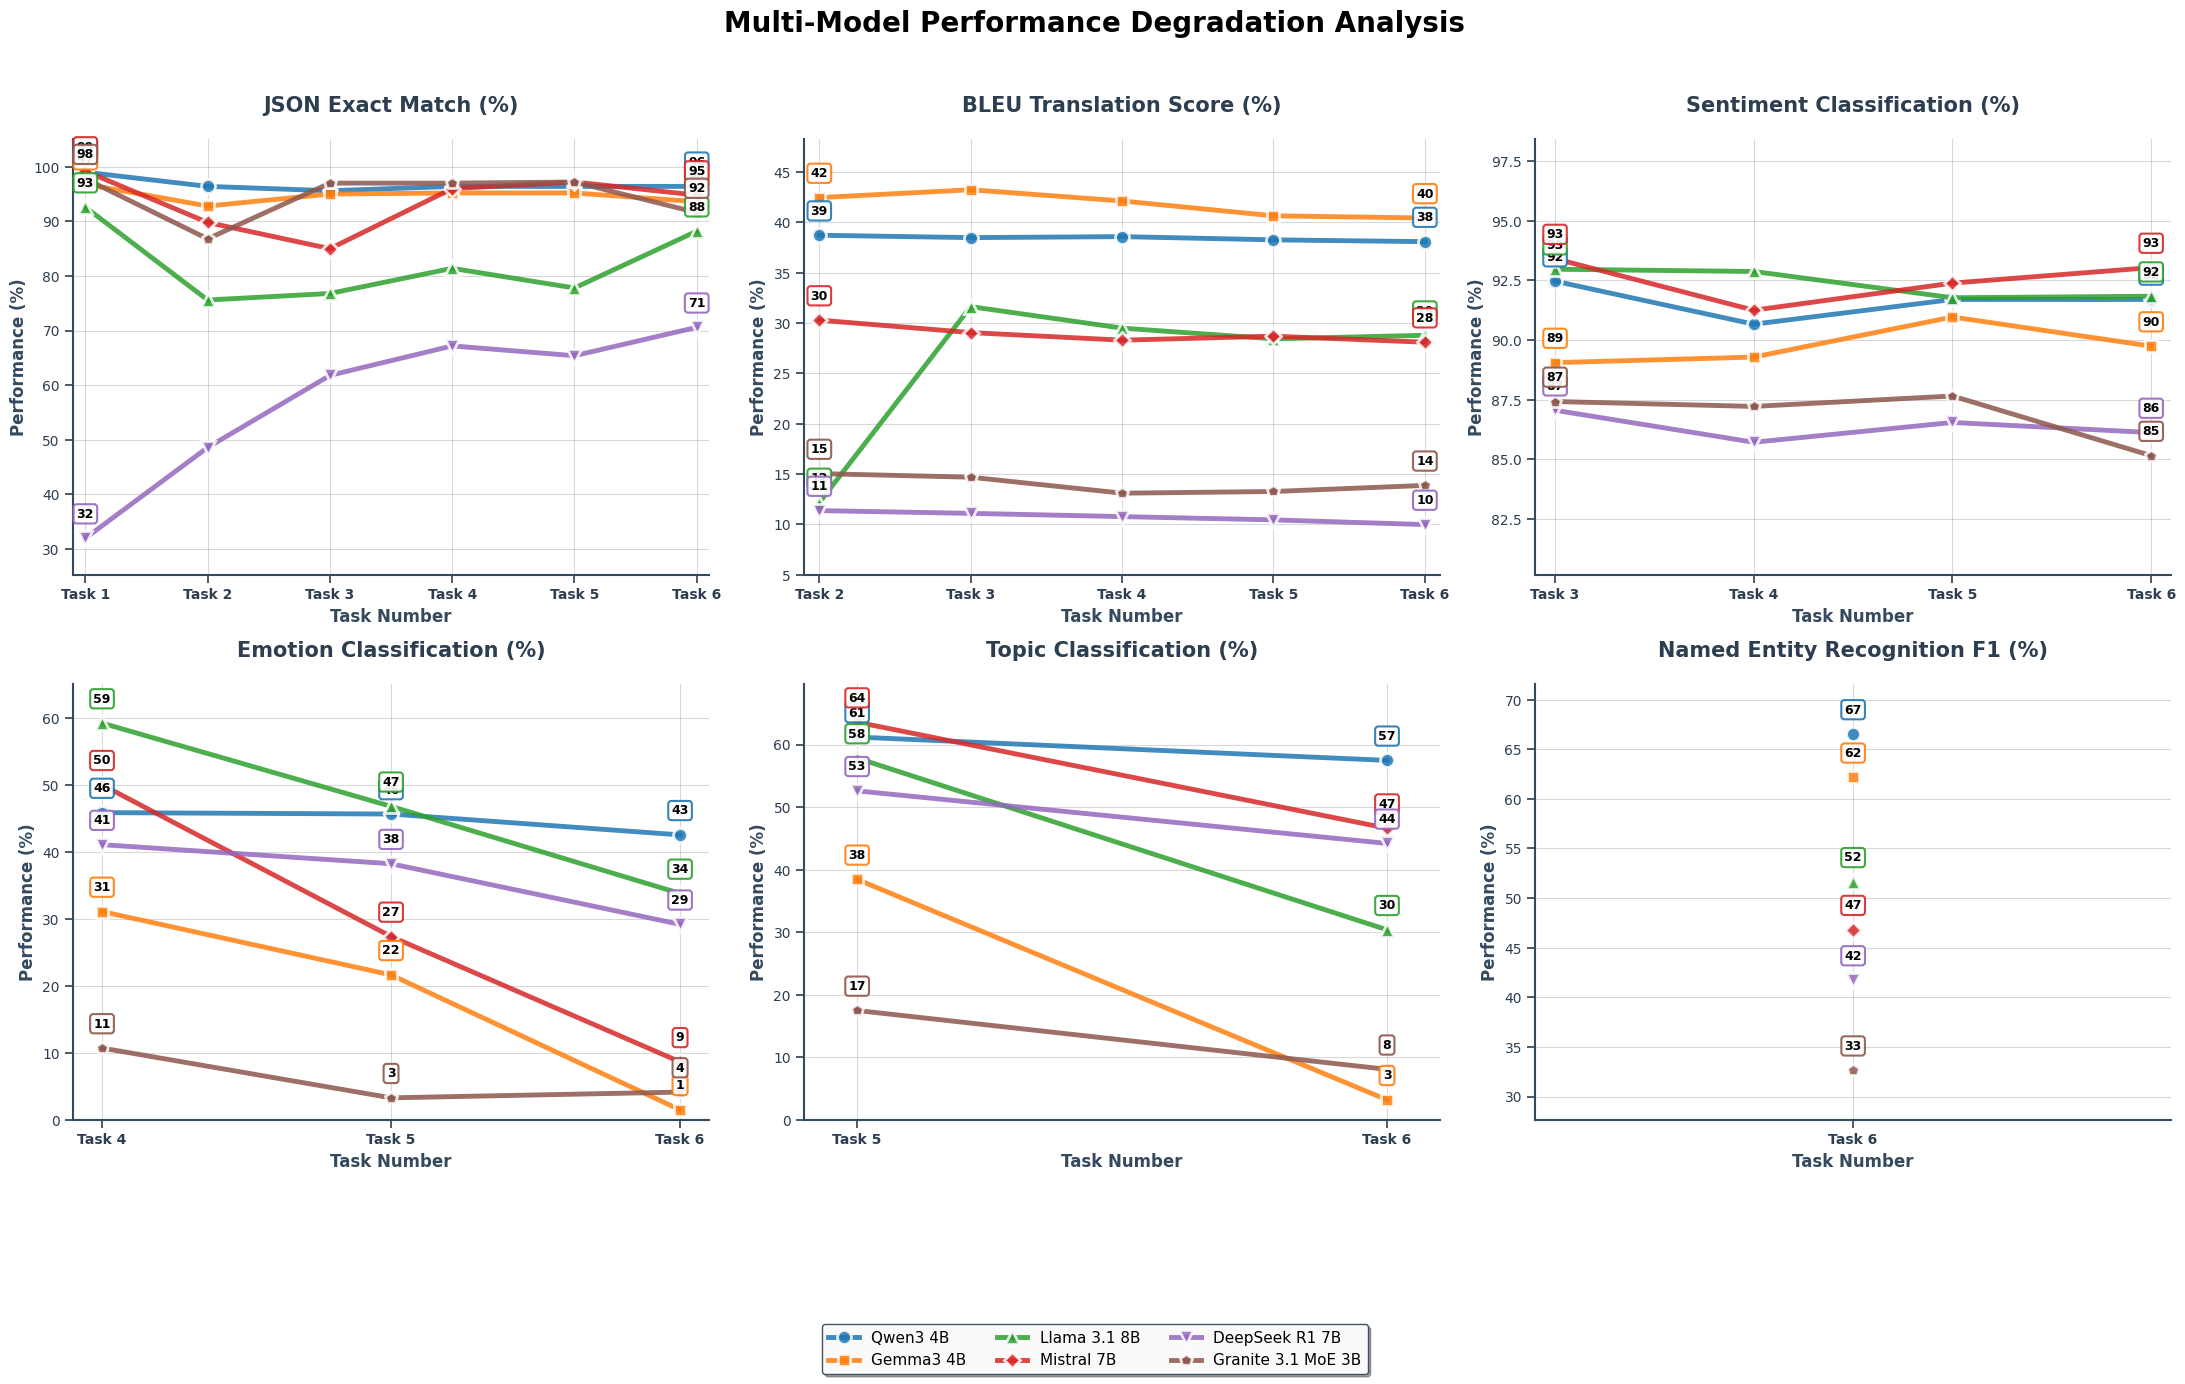

✅ Grafico overview salvato
🎨 Generazione grafico performance change...
Qwen3 4B - json_em: 99.0% → 96.4% (degradazione: -2.6%)
Qwen3 4B - bleu_translate: 38.7% → 38.1% (degradazione: -1.6%)
Qwen3 4B - em_sentiment: 92.5% → 91.7% (degradazione: -0.8%)
Qwen3 4B - em_emotion: 45.9% → 42.5% (degradazione: -7.2%)
Qwen3 4B - em_topic: 61.2% → 57.5% (degradazione: -6.1%)
Qwen3 4B - Degradazione medio: -3.7%

Gemma3 4B - json_em: 96.8% → 93.6% (degradazione: -3.3%)
Gemma3 4B - bleu_translate: 42.5% → 40.4% (degradazione: -4.8%)
Gemma3 4B - em_sentiment: 89.1% → 89.7% (miglioramento: +0.8%)
Gemma3 4B - em_emotion: 31.1% → 1.5% (degradazione: -95.2%)
Gemma3 4B - em_topic: 38.4% → 3.2% (degradazione: -91.7%)
Gemma3 4B - Degradazione medio: -38.8%

Llama 3.1 8B - json_em: 92.6% → 88.2% (degradazione: -4.8%)
Llama 3.1 8B - bleu_translate: 12.2% → 28.8% (miglioramento: +136.7%)
Llama 3.1 8B - em_sentiment: 93.0% → 91.8% (degradazione: -1.2%)
Llama 3.1 8B - em_emotion: 59.2% → 33.8% (degradazione: -4

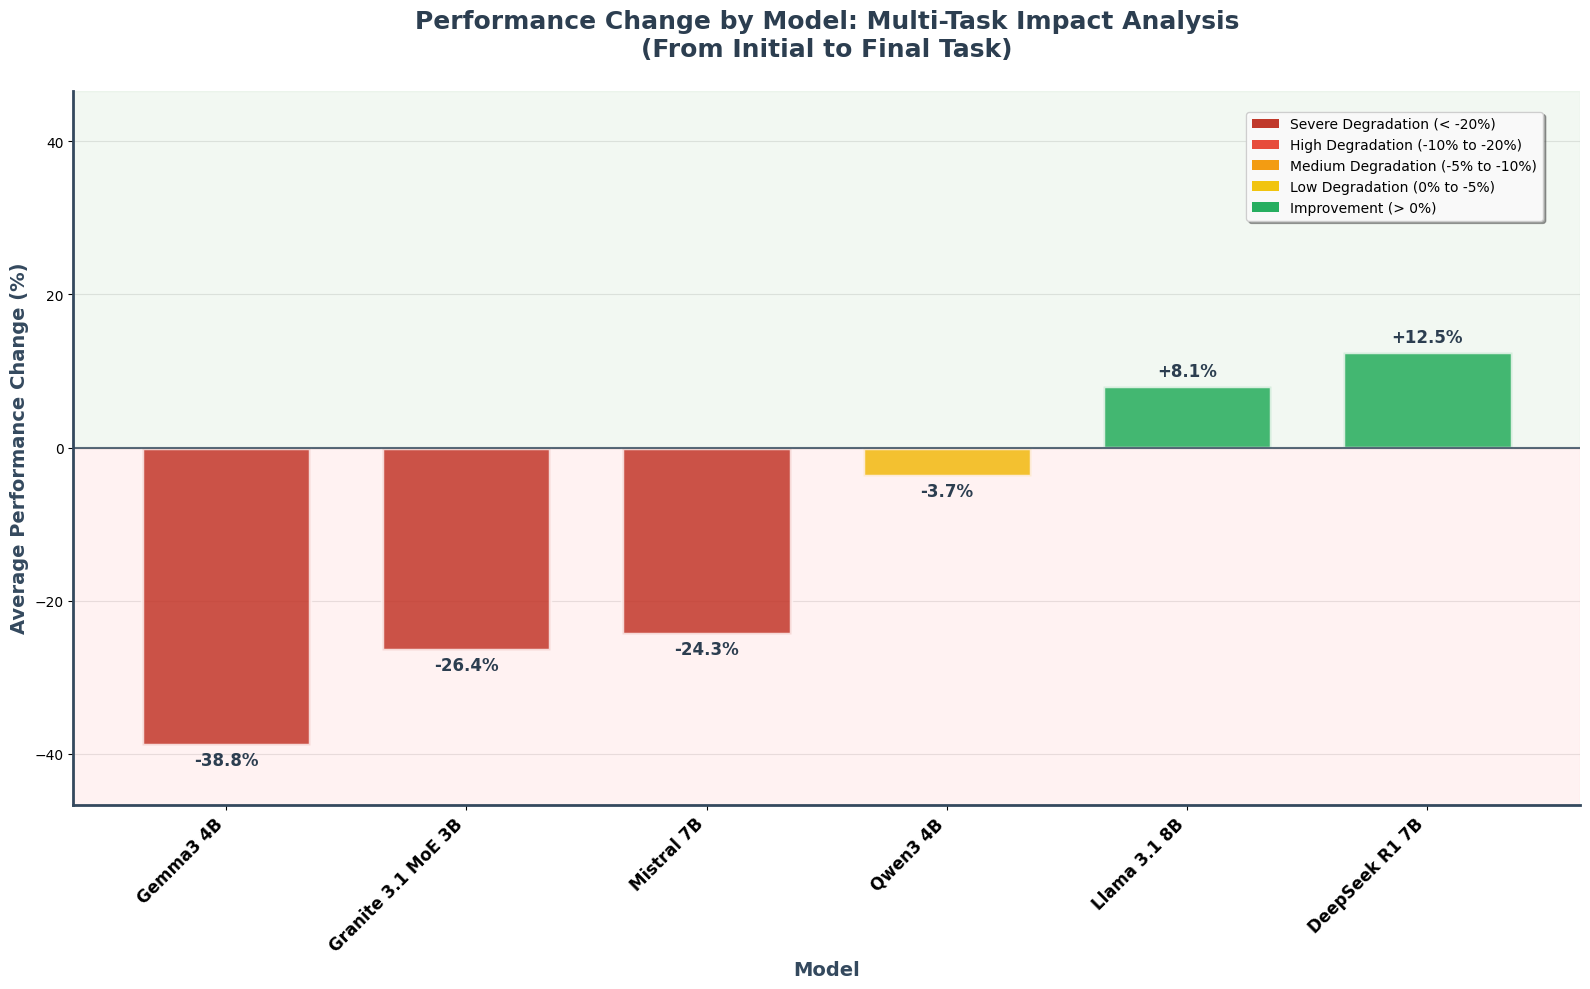

✅ Grafico analisi performance salvato

RIEPILOGO IMPATTO MULTI-TASK SUI MODELLI
Gemma3 4B           : DEGRADA del 38.8%    (su 5 metriche)
Granite 3.1 MoE 3B  : DEGRADA del 26.4%    (su 5 metriche)
Mistral 7B          : DEGRADA del 24.3%    (su 5 metriche)
Qwen3 4B            : DEGRADA del 3.7%     (su 5 metriche)
Llama 3.1 8B        : MIGLIORA del 8.1%    (su 5 metriche)
DeepSeek R1 7B      : MIGLIORA del 12.5%   (su 5 metriche)

🏆 MIGLIORE (meno degradazione): DeepSeek R1 7B
❌ PEGGIORE (più degradazione):   Gemma3 4B
📊 Generazione grafico performance assolute finali...
Qwen3 4B - Performance media Task 6: 65.5% (su 6 metriche)
Gemma3 4B - Performance media Task 6: 48.4% (su 6 metriche)
Llama 3.1 8B - Performance media Task 6: 54.1% (su 6 metriche)
Mistral 7B - Performance media Task 6: 53.0% (su 6 metriche)
DeepSeek R1 7B - Performance media Task 6: 47.0% (su 6 metriche)
Granite 3.1 MoE 3B - Performance media Task 6: 39.2% (su 6 metriche)


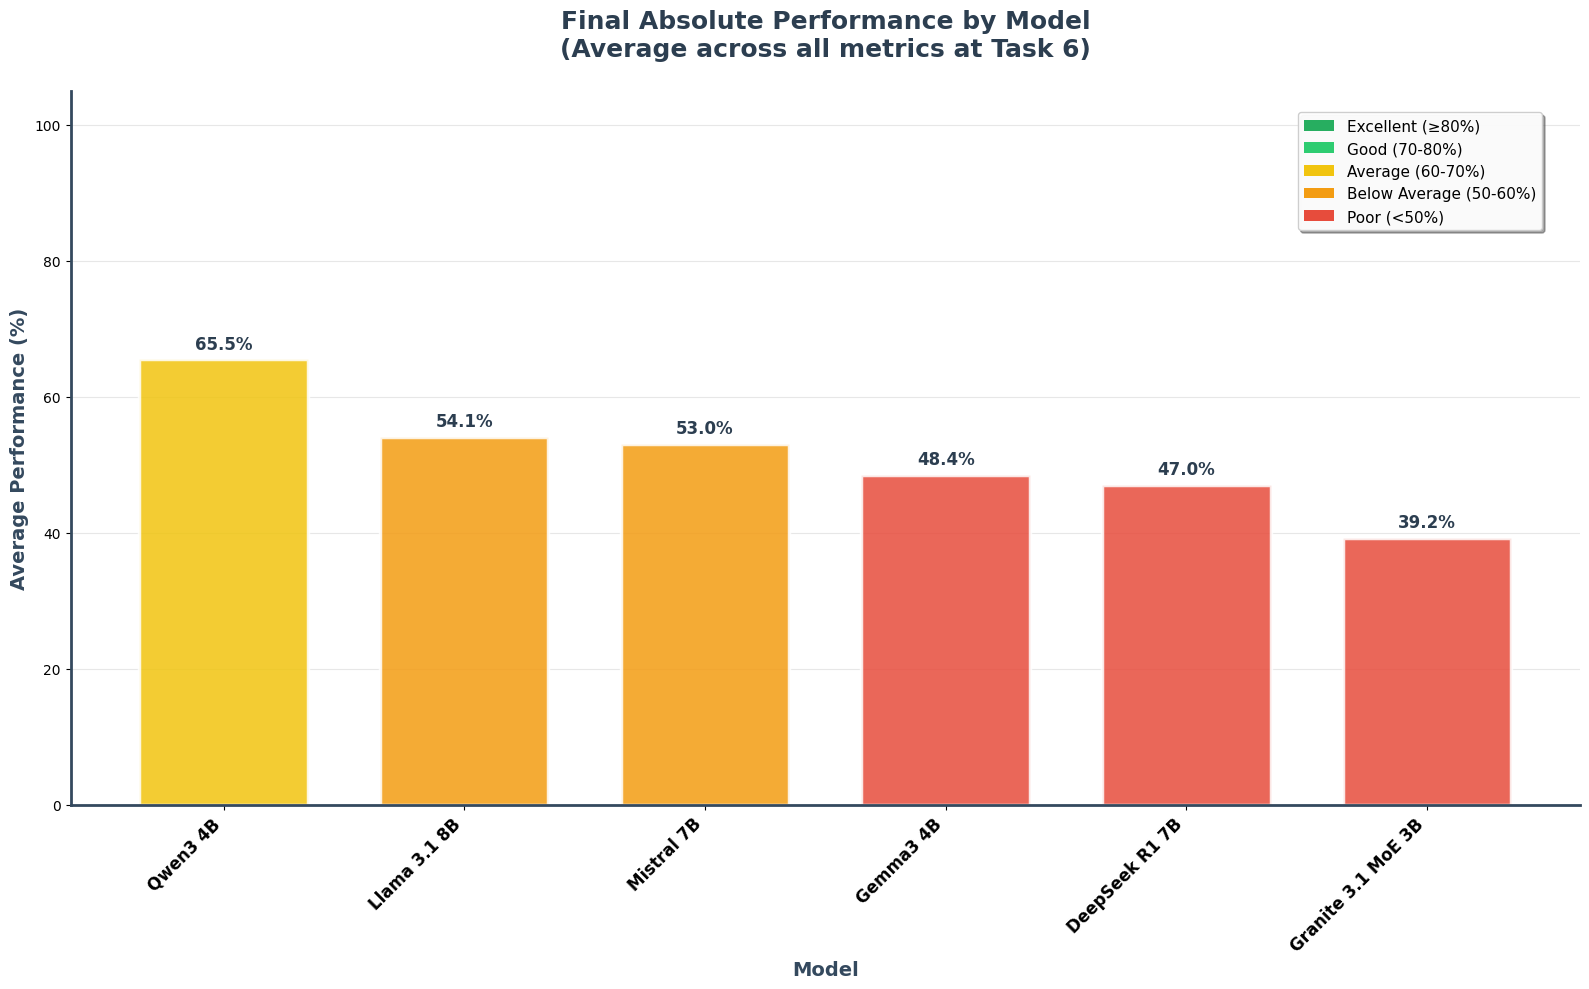

✅ Grafico performance assolute salvato

RANKING PERFORMANCE ASSOLUTE FINALI (TASK 6)
 1. Qwen3 4B            :  65.5% (su 6 metriche)
 2. Llama 3.1 8B        :  54.1% (su 6 metriche)
 3. Mistral 7B          :  53.0% (su 6 metriche)
 4. Gemma3 4B           :  48.4% (su 6 metriche)
 5. DeepSeek R1 7B      :  47.0% (su 6 metriche)
 6. Granite 3.1 MoE 3B  :  39.2% (su 6 metriche)

🥇 MIGLIORE PERFORMANCE ASSOLUTA: Qwen3 4B (65.5%)
🥉 PERFORMANCE PIU' BASSA:        Granite 3.1 MoE 3B (39.2%)
💾 Salvataggio dati riassuntivi...
✅ CSV riassuntivo salvato: ../Output Performance Degradation Analysis/multi_model_summary_final.csv

✅ ANALISI MULTI-MODELLO COMPLETATA!
📁 Output salvato in: ../Output Performance Degradation Analysis/
📊 File generati:
   - multi_model_final_performance_comparison_corrected.png
   - multi_model_performance_degradation_overview_final.png
   - overall_model_performance_change_analysis_final.png
   - absolute_final_performance_comparison_final.png
   - multi_model_summary_fi

In [16]:
if __name__ == "__main__":
    print("🎨 Generazione grafico comparativo delle performance finali...")
    create_final_performance_comparison(final_data, output_dir)

    print("🎨 Generazione grafico overview degradazione...")
    create_degradation_overview(degradation_data, output_dir)

    print("🎨 Generazione grafico performance change...")
    create_overall_degradation_chart(final_data, output_dir)

    print("📊 Generazione grafico performance assolute finali...")
    absolute_ranking = create_absolute_performance_chart(final_data, output_dir)

    # Salvataggio dati riassuntivi
    print("💾 Salvataggio dati riassuntivi...")
    summary_rows = []
    for model_name, model_data in final_data.items():
        for task, metrics in model_data.items():
            for metric, value in metrics.items():
                summary_rows.append({
                    'model': MODEL_DISPLAY_NAMES[model_name],
                    'task': task,
                    'metric': metric,
                    'value': value
                })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(f'{output_dir}/multi_model_summary_final.csv', index=False)
    print(f"✅ CSV riassuntivo salvato: {output_dir}/multi_model_summary_final.csv")

    print("\n" + "=" * 60)
    print("✅ ANALISI MULTI-MODELLO COMPLETATA!")
    print("=" * 60)
    print(f"📁 Output salvato in: {output_dir}/")
    print("📊 File generati:")
    print("   - multi_model_final_performance_comparison_corrected.png")
    print("   - multi_model_performance_degradation_overview_final.png") 
    print("   - overall_model_performance_change_analysis_final.png")
    print("   - absolute_final_performance_comparison_final.png")
    print("   - multi_model_summary_final.csv")
    print("\n🎯 CORREZIONI APPLICATE:")
    print("   ✓ Formula corretta: ((finale - iniziale) / iniziale) * 100")
    print("   ✓ Nomi modelli semplificati (es. 'Qwen3 4B' invece di tag completi)")
    print("   ✓ Legenda Performance Change semplificata (un solo verde)")
    print("   ✓ Rimosse descrizioni verdi dai grafici")
    print("   ✓ Segni corretti: negativo = degradazione, positivo = miglioramento")